# **Tutorial:** Custom YOLO Object Detection with RoboFlow

In this tutorial, you'll learn how to create a custom YOLO object detection model using your own classes and annotations with RoboFlow.

### **Step 1: Install Required Dependencies**

In [2]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\brand\anaconda3\envs\dev\python.exe C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a68654d6e9d47b846c987ed4e\vendored-meson\meson\meson.py setup C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a68654d6e9d47b846c987ed4e C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a68654d6e9d47b846c987ed4e\.mesonpy-oe0tfsx6 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a68654d6e9d47b846c987ed4e\.mesonpy-oe0tfsx6\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a68654d6e9d47b846c987ed4e
      Build dir: C:\Users\brand\AppData\Local\Temp\pip-install-pd_3xf4k\numpy_096e098a6

### **Step 2: Import Required Libraries**

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Necesario para evitar que muera el kernel
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

In [ ]:
# Initialize RoboFlow (you'll need your API key)

from roboflow import Roboflow
rf = Roboflow(api_key="eGFYeFonZgeWFCSZdR7E")
project = rf.workspace("brandons-workspace-dklql").project("tareasemana3")
dataset = project.version(3).download("yolo26") # Se crearon multiples versiones con diferentes balances del dataset la version 3 fue la mas confiable

loading Roboflow workspace...
loading Roboflow project...


### **Step 6: Train Your Custom YOLO Model**

In [ ]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=50,  # Se aumento de 20 -> 50 para mejorar el entrenamiento, este fue el numero encontrado para que el modelo sea capaz de detectar las formas en vivo en video
    imgsz=640,  # Se mantuvo la calidad de imagen para evitar perdidas de calidad
    batch=8,   # Se paso de 16 -> 8 para evitar que se consuma demasiada memoria
    name='yolo_clase_3',  # Name for the training run
    device='cuda' # Se agrego para forzar el uso de la GPU en lugar de la CPU
)

Ultralytics 8.4.26  Python-3.13.11 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\brand\Documents\GitHub\vision-por-computador\ejercicio_clase3\TareaSemana3-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_clase_3, nbs=64, nms=False, ops

### **Step 7: Evaluate Your Model**

In [4]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
    
# Show some validation results
!yolo task=detect mode=val model=runs/detect/yolo_clase_3/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.26  Python-3.13.11 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 492.484.8 MB/s, size: 21.6 KB)
val: Scanning C:\Users\brand\Documents\GitHub\vision-por-computador\ejercicio_clase3\TareaSemana3-3\valid\labels.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 9.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.7s8.5s
                   all         25         25      0.883      0.824      0.952       0.87
            Dinosaurio         12         12      0.937      0.833      0.968      0.889
                Llaves          9          9      0.836      0.889      0.975      0.892
                   Pin          4          4      0.877       0.75      0.912      0.829
Speed: 6.0ms preprocess, 14.5ms inference, 0.0ms loss, 0.

### **Step 8: Test Your Custom Model on an Image**


image 1/1 C:\Users\brand\Downloads\Dinosaurio (8).jpeg: 640x480 1 Dinosaurio, 22.5ms
Speed: 2.7ms preprocess, 22.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


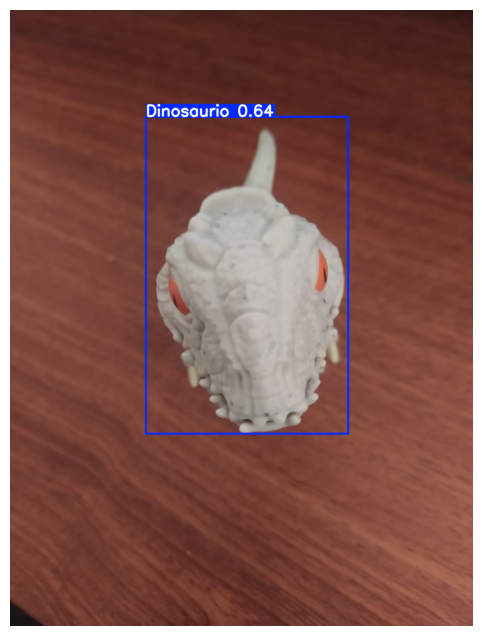

In [13]:
# Load your custom trained model
custom_model = YOLO('C:/Users/brand/Documents/GitHub/vision-por-computador/ejercicio_clase3/runs/detect/yolo_clase_3/weights/best.pt')

# Test on a sample image
results = model("C:/Users/brand/Downloads/Dinosaurio (8).jpeg", conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
    
   

### **Step 9: Test Your Custom Model on Video**

Cámara cerrada.


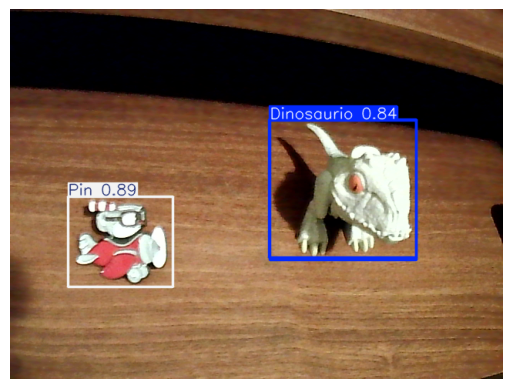

In [ ]:
# Se recargan las librerias necesarias para evitar errores en la captura
import cv2
from ultralytics import YOLO
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Carga del modelo entrenado
model = YOLO("runs/detect/yolo_clase_3/weights/best.pt")

# Inicia la camara
cap = cv2.VideoCapture(0)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Se realiza la prediccion en los frames del video
        results = model(frame)
        annotated_frame = results[0].plot()

        # Se le agrega un label a la deteccion de cada frame
        annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

        # Muestra el frame
        plt.imshow(annotated_frame)
        plt.axis('off')
        clear_output(wait=True)
        display(plt.gcf())

except KeyboardInterrupt:
    # Salir con ctrl c para cerrar la camara
    print("Cámara cerrada.")

finally:
    # Se asegura el cierre de la camaara
    cap.release()
    clear_output(wait=True)

## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 25 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 4 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 1 | Properly trains a YOLOv8 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 1 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 3 | Implements real-time detection with custom classes and displays results correctly. You have to use video from your webcam, no images or saved videos allowed. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>